In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os

DATA_DIR = '../数据'
df = pd.read_csv(os.path.join(DATA_DIR, 'processed_jobs.csv'))
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

#### 薪资分布直方图

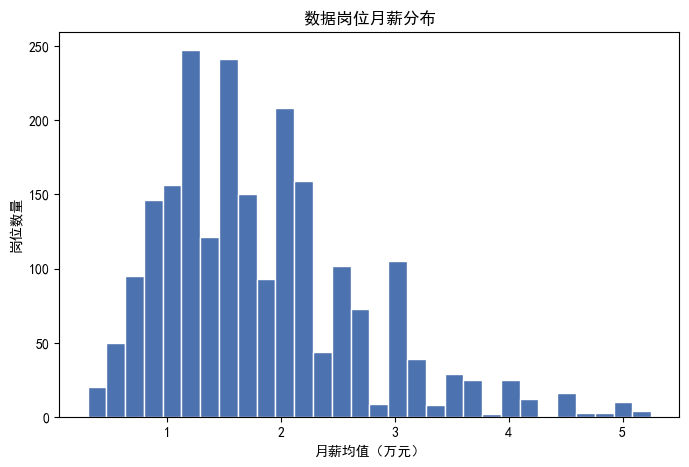

In [2]:
plt.figure(figsize=(8, 5))
plt.hist(df['月薪均值'], bins=30, color='#4C72B0', edgecolor='white')
plt.xlabel('月薪均值（万元）')
plt.ylabel('岗位数量')
plt.title('数据岗位月薪分布')
plt.show()

#### 各城市薪资箱线图对比

In [3]:
df['城市'] = df['工作城市'].str.split('·').str[0]
city_order = df.groupby('城市')['月薪均值'].median().sort_values(ascending=False).index

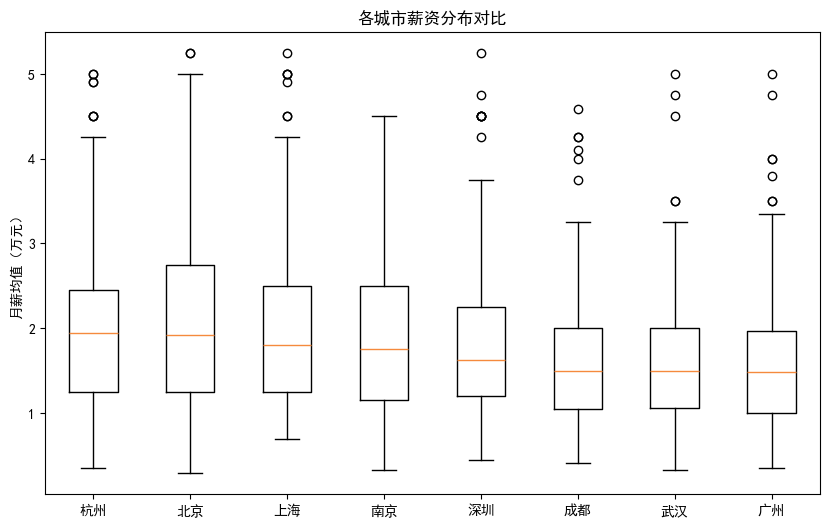

In [4]:
plt.figure(figsize=(10, 6))
plt.boxplot([df[df['城市'] == c]['月薪均值'] for c in city_order], tick_labels=city_order)
plt.ylabel('月薪均值（万元）')
plt.title('各城市薪资分布对比')
plt.show()

#### 学历/经验与薪资的关系柱状图

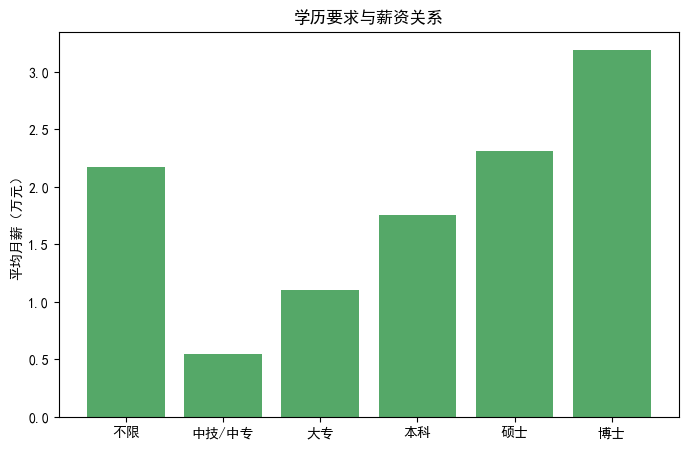

In [5]:
edu_order = ['不限', '中技/中专', '大专', '本科', '硕士', '博士']
edu_salary = df.groupby('学历要求')['月薪均值'].mean().reindex(edu_order)

plt.figure(figsize=(8, 5))
plt.bar(edu_salary.index, edu_salary.values, color='#55A868')
plt.ylabel('平均月薪（万元）')
plt.title('学历要求与薪资关系')
plt.show()

C:\Users\MouKexin\AppData\Local\Temp\ipykernel_23360\4264893543.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  exp_salary = df.groupby('经验分段')['月薪均值'].mean()


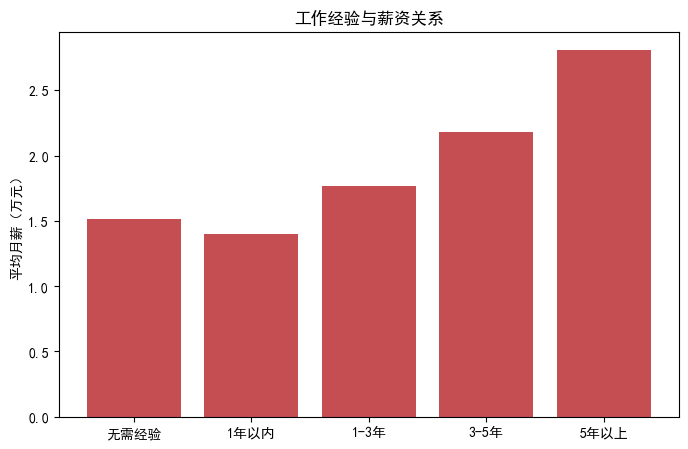

In [6]:
bins = [-1, 0, 1, 3, 5, 100]
labels = ['无需经验', '1年以内', '1-3年', '3-5年', '5年以上']
df['经验分段'] = pd.cut(df['经验年限'], bins=bins, labels=labels)
exp_salary = df.groupby('经验分段')['月薪均值'].mean()

plt.figure(figsize=(8, 5))
plt.bar(exp_salary.index, exp_salary.values, color='#C44E52')
plt.ylabel('平均月薪（万元）')
plt.title('工作经验与薪资关系')
plt.show()

#### 公司规模 × 公司性质 薪资热力图

In [7]:
import seaborn as sns

nature_cols = [c for c in df.columns if c.startswith('公司性质_')]
df['公司性质'] = df[nature_cols].idxmax(axis=1).str.replace('公司性质_', '')

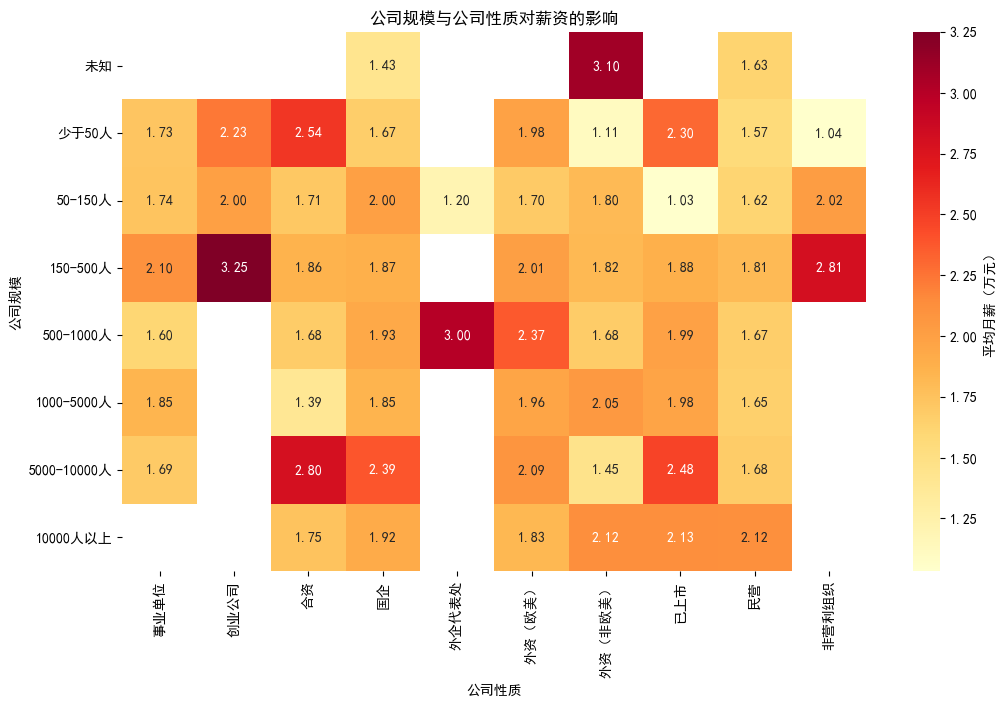

In [8]:
size_order = ['未知', '少于50人', '50-150人', '150-500人', '500-1000人', '1000-5000人', '5000-10000人', '10000人以上']
pivot = df.pivot_table(index='公司规模', columns='公司性质', values='月薪均值', aggfunc='mean').reindex(size_order)

plt.figure(figsize=(12, 7))
sns.heatmap(pivot, annot=True, fmt='.2f', cmap='YlOrRd', cbar_kws={'label': '平均月薪（万元）'})
plt.title('公司规模与公司性质对薪资的影响')
plt.xlabel('公司性质')
plt.ylabel('公司规模')
plt.show()

#### 高频技能词云图

In [9]:
from collections import Counter

benefit_words = {
    '五险一金', '年终奖金', '定期体检', '带薪年假', '绩效奖金', '周末双休',
    '餐饮补贴', '节日福利', '补充医疗保险', '通讯补贴', '员工旅游', '交通补贴',
    '弹性工作', '免费班车', '有餐补', '带薪病假', '定期团建', '出差补贴',
    '股票期权', '出国机会', '零食下午茶', '双休', '六险一金', '五险',
    '团队氛围好', '补充公积金', '项目奖金', '专业培训', '培训'
}

all_tags = []
for s in df['技能标签'].dropna():
    all_tags.extend(t for t in s.split(',') if t and t not in benefit_words)

tag_freq = Counter(all_tags)
tag_freq.most_common(20)

[('计算机', 526),
 ('数据分析', 522),
 ('ai', 414),
 ('人工智能', 342),
 ('机器学习', 291),
 ('数学', 285),
 ('sql', 274),
 ('c++', 244),
 ('深度学习', 206),
 ('java', 173),
 ('excel', 167),
 ('自动化', 161),
 ('数据库', 149),
 ('算法', 149),
 ('软件工程', 141),
 ('编程语言', 137),
 ('python', 133),
 ('linux', 120),
 ('编程', 118),
 ('计算机科学', 113)]

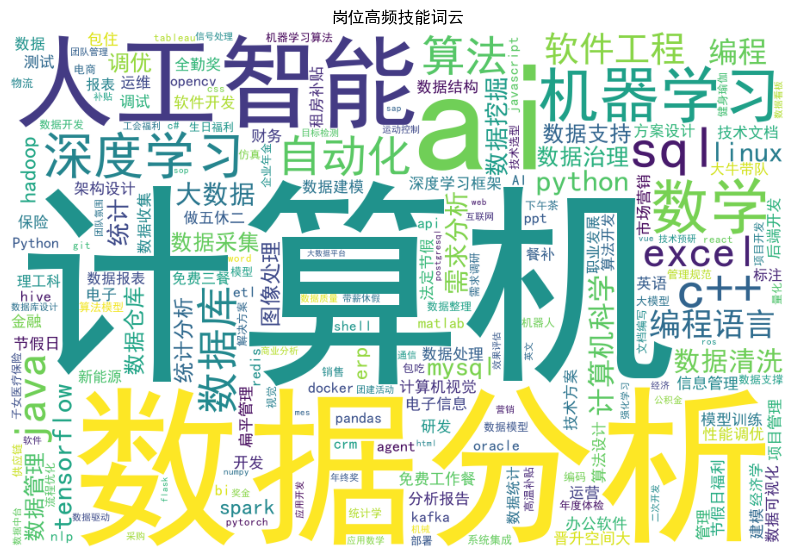

In [10]:
from wordcloud import WordCloud

wc = WordCloud(font_path='C:/Windows/Fonts/simhei.ttf', width=900, height=600, background_color='white')
wc.generate_from_frequencies(tag_freq)

plt.figure(figsize=(10, 7))
plt.imshow(wc)
plt.axis('off')
plt.title('岗位高频技能词云')
plt.show()